# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [6]:
type(registros)

list

In [7]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [4]:
dados = pd.DataFrame(registros)

print("=== Primeiros registros ===")
display(dados.head())

n_linhas, n_colunas = dados.shape
print(f"\nQuantidade de linhas: {n_linhas}")
print(f"Quantidade de colunas: {n_colunas}")

print("\nNomes dos atributos:")
print(list(dados.columns))

print("\n=== dados.info() ===")
dados.info()

print("\n=== dados.describe() ===")
display(dados.describe(include="all"))

# identificação automática das colunas-chave

def encontrar_coluna(candidatos_exatos, palavras_chave, colunas):
    cols_lower = {c.lower(): c for c in colunas}
    for cand in candidatos_exatos:
        if cand in cols_lower:
            return cols_lower[cand]
    for c in colunas:
        cl = c.lower()
        if any(p in cl for p in palavras_chave):
            return c
    return None

col_data = encontrar_coluna(
    ["din_referenciautc", "din_referencia", "data", "datetime"],
    ["din_referencia", "data", "timestamp", "hora"],
    dados.columns,
)
col_area = encontrar_coluna(
    ["cod_areacarga", "nom_areacarga", "area"],
    ["areacarga", "area"],
    dados.columns,
)
col_carga = encontrar_coluna(
    ["val_cargaglobal", "val_carga", "carga"],
    ["val_carga", "carga"],
    [c for c in dados.columns if c not in (col_data, col_area)],
)

print("\nColuna identificada como DATA/HORA :", col_data)
print("Coluna identificada como ÁREA DE CARGA:", col_area)
print("Coluna identificada como VALOR DE CARGA:", col_carga)

=== Primeiros registros ===


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

=== dados.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    str    
 1   din_atualizacao             336 non-null    str    
 2   dat_referencia              336 non-null    str    
 3   din_referenciautc           336 non-null    str    
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8 

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0



Coluna identificada como DATA/HORA : din_referenciautc
Coluna identificada como ÁREA DE CARGA: cod_areacarga
Coluna identificada como VALOR DE CARGA: val_cargaglobal


**Identificação dos atributos:**

Com base na saída de `dados.columns` e na identificação automática feita acima:

- **Data/hora da medição:** coluna `col_data` impressa acima (ex.: algo como `din_referenciautc`).
- **Área de carga:** coluna `col_area` impressa acima (ex.: `cod_areacarga`, com o valor `"SP"`).
- **Valor de carga:** coluna `col_carga` impressa acima (ex.: `val_cargaglobal`), representando a carga verificada em MWmed.



## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [5]:
# renomear os atributos principais para nomes simples
dados_renomeados = dados.rename(columns={
    col_data: "data_hora",
    col_area: "area",
    col_carga: "carga_mw",
})

# novo dataframe apenas com os atributos necessários
dados_organizados = dados_renomeados[["data_hora", "area", "carga_mw"]].copy()

print("=== Amostra do DataFrame organizado ===")
display(dados_organizados.head())

# valores ausentes
print("\nValores ausentes por atributo:")
print(dados_organizados.isna().sum())

# a carga está em formato numérico?
print("\nTipo de 'carga_mw' antes do tratamento:", dados_organizados["carga_mw"].dtype)
dados_organizados["carga_mw"] = pd.to_numeric(dados_organizados["carga_mw"], errors="coerce")
print("Tipo de 'carga_mw' depois de pd.to_numeric:", dados_organizados["carga_mw"].dtype)

# como a data/hora está representada?
print("\nTipo de 'data_hora' antes do tratamento:", dados_organizados["data_hora"].dtype)
print("Exemplo de valor bruto:", dados_organizados["data_hora"].iloc[0])
dados_organizados["data_hora"] = pd.to_datetime(dados_organizados["data_hora"], errors="coerce")
print("Tipo de 'data_hora' depois de pd.to_datetime:", dados_organizados["data_hora"].dtype)

# reconfere valores ausentes após as conversões (coerce pode gerar NaN/NaT)
print("\nValores ausentes após conversão de tipos:")
print(dados_organizados.isna().sum())

display(dados_organizados.head())

=== Amostra do DataFrame organizado ===


,data_hora,area,carga_mw
0,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01T05:30:00.000Z,SP,13838.488



Valores ausentes por atributo:
data_hora    0
area         0
carga_mw     0
dtype: int64

Tipo de 'carga_mw' antes do tratamento: float64
Tipo de 'carga_mw' depois de pd.to_numeric: float64

Tipo de 'data_hora' antes do tratamento: str
Exemplo de valor bruto: 2025-08-01T03:30:00.000Z
Tipo de 'data_hora' depois de pd.to_datetime: datetime64[us, UTC]

Valores ausentes após conversão de tipos:
data_hora    0
area         0
carga_mw     0
dtype: int64


,data_hora,area,carga_mw
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488


**decisões de tratamento:**

- Os atributos foram renomeados para `data_hora`, `area` e `carga_mw` para facilitar a leitura do código.
- `carga_mw` foi convertido para numérico com `pd.to_numeric(..., errors="coerce")`.
- `data_hora` foi convertido para `datetime` com `pd.to_datetime(..., errors="coerce")`, permitindo ordenar e filtrar por data/hora.
- Não foram encontrados valores ausentes nas três colunas relevantes: `data_hora = 0`, `area = 0` e `carga_mw = 0`.
- A conversão não gerou novos valores ausentes. A coluna `carga_mw` permaneceu em `float64` e `data_hora` passou para `datetime64[us, UTC]`.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [6]:
carga_minima = dados_organizados["carga_mw"].min()
carga_maxima = dados_organizados["carga_mw"].max()
carga_media = dados_organizados["carga_mw"].mean()
carga_mediana = dados_organizados["carga_mw"].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados_organizados["carga_mw"].count()

print(f"Carga mínima  : {carga_minima:.2f} MWmed")
print(f"Carga máxima  : {carga_maxima:.2f} MWmed")
print(f"Carga média   : {carga_media:.2f} MWmed")
print(f"Mediana       : {carga_mediana:.2f} MWmed")
print(f"Amplitude     : {amplitude:.2f} MWmed")
print(f"Total de medições: {total_medicoes}")

distancia_max_media_pct = (carga_maxima - carga_media) / carga_media * 100
print(f"\nA carga máxima está {distancia_max_media_pct:.1f}% acima da carga média.")

Carga mínima  : 12139.25 MWmed
Carga máxima  : 23185.31 MWmed
Carga média   : 17870.83 MWmed
Mediana       : 18199.13 MWmed
Amplitude     : 11046.06 MWmed
Total de medições: 336

A carga máxima está 29.7% acima da carga média.


**Resposta:** O valor máximo está relativamente distante do comportamento médio. A carga máxima foi de **23.185,31 MWmed**, enquanto a média foi de **17.870,83 MWmed** e a mediana de **18.199,13 MWmed**. O máximo ficou **29,7% acima da média**, indicando um pico relevante acima do comportamento típico observado no período.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [7]:
# limiar de alta demanda (90% da carga máxima)
limiar_alta_demanda = 0.90 * carga_maxima
print(f"Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed")

# novo dataframe com os registros acima do limiar
dados_alta_demanda = dados_organizados[dados_organizados["carga_mw"] > limiar_alta_demanda].copy()

# contagem de registros
qtd_alta_demanda = len(dados_alta_demanda)
print(f"Registros em alta demanda: {qtd_alta_demanda}")

# percentual em relação ao total
pct_alta_demanda = qtd_alta_demanda / total_medicoes * 100
print(f"Percentual do total: {pct_alta_demanda:.2f}%")

# maior valor de carga (pico)
pico_valor = dados_organizados["carga_mw"].max()
print(f"Valor de pico: {pico_valor:.2f} MWmed")

# data/horário do pico, quando disponivel
linha_pico = dados_organizados.loc[dados_organizados["carga_mw"].idxmax()]
momento_pico = linha_pico["data_hora"]
print(f"Momento do pico: {momento_pico}")

display(dados_alta_demanda.head())

Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros em alta demanda: 50
Percentual do total: 14.88%
Valor de pico: 23185.31 MWmed
Momento do pico: 2025-08-01 22:00:00+00:00


,data_hora,area,carga_mw
35,2025-08-01 21:00:00+00:00,SP,21088.959
36,2025-08-01 21:30:00+00:00,SP,22398.360
37,2025-08-01 22:00:00+00:00,SP,23185.312
38,2025-08-01 22:30:00+00:00,SP,22903.314
39,2025-08-01 23:00:00+00:00,SP,22358.701


Os períodos próximos ao pico representam uma **parcela pequena** do período analisado. Foram identificados **50 registros de alta demanda**, equivalentes a **14,88%** das 336 medições. Portanto, embora existam várias ocorrências acima de 90% do máximo, elas não correspondem à maior parte das observações.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [8]:
# critério escolhido: registros com carga ACIMA DA MÉDIA.

criterio_desafio5 = "Carga acima da média (carga_mw > carga_media)"
print("Critério escolhido:", criterio_desafio5)

dados_criterio2 = dados_organizados[dados_organizados["carga_mw"] > carga_media].copy()

qtd_criterio2 = len(dados_criterio2)
pct_criterio2 = qtd_criterio2 / total_medicoes * 100

print(f"Quantidade de registros: {qtd_criterio2}")
print(f"Percentual do total: {pct_criterio2:.2f}%")

print("\nComparação com o conjunto de alta demanda (Desafio 4):")
print(f" - Alta demanda (>90% do máximo): {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)")
print(f" - Acima da média              : {qtd_criterio2} registros ({pct_criterio2:.2f}%)")

display(dados_criterio2.head())

Critério escolhido: Carga acima da média (carga_mw > carga_media)
Quantidade de registros: 184
Percentual do total: 54.76%

Comparação com o conjunto de alta demanda (Desafio 4):
 - Alta demanda (>90% do máximo): 50 registros (14.88%)
 - Acima da média              : 184 registros (54.76%)


,data_hora,area,carga_mw
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

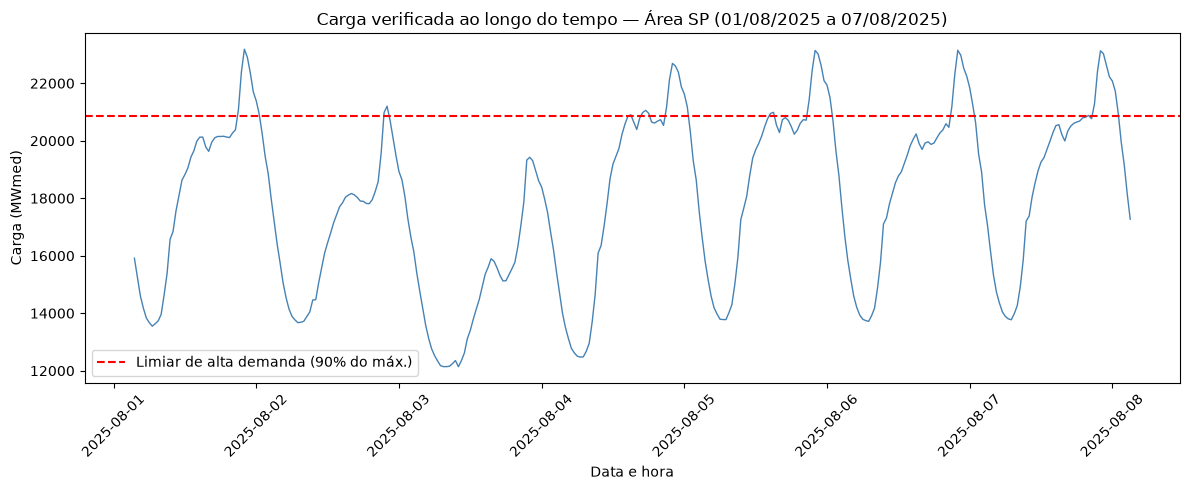

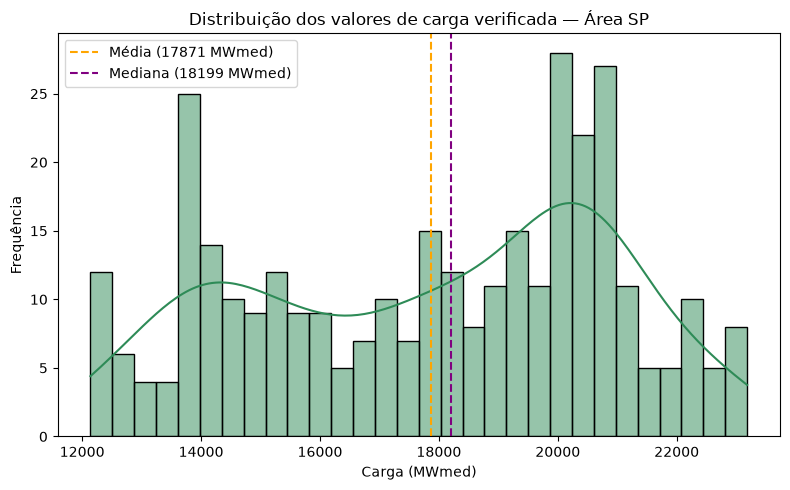

In [9]:
dados_ordenados = dados_organizados.sort_values("data_hora")

# Gráfico 1 — comportamento da carga ao longo do tempo
plt.figure(figsize=(12, 5))
plt.plot(dados_ordenados["data_hora"], dados_ordenados["carga_mw"], color="steelblue", linewidth=1)
plt.axhline(limiar_alta_demanda, color="red", linestyle="--", label="Limiar de alta demanda (90% do máx.)")
plt.title("Carga verificada ao longo do tempo — Área SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data e hora")
plt.ylabel("Carga (MWmed)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2 — distribuição dos valores de carga (histograma)
plt.figure(figsize=(8, 5))
sns.histplot(dados_organizados["carga_mw"], bins=30, color="seagreen", kde=True)
plt.axvline(carga_media, color="orange", linestyle="--", label=f"Média ({carga_media:.0f} MWmed)")
plt.axvline(carga_mediana, color="purple", linestyle="--", label=f"Mediana ({carga_mediana:.0f} MWmed)")
plt.title("Distribuição dos valores de carga verificada — Área SP")
plt.xlabel("Carga (MWmed)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

**interpretação dos gráficos:**

- **gráfico 1 — série temporal:** observa-se um comportamento cíclico da carga, com valores mais baixos em determinados períodos e elevações recorrentes ao longo dos dias. o limiar de 90% do máximo permite visualizar que os maiores picos ficam concentrados em uma parcela menor das observações.
- **gráfico 2 — histograma:** os valores apresentam concentração em uma faixa central, próxima da média e da mediana, mas também há uma quantidade relevante de valores elevados. isso ajuda a explicar por que o máximo (23.185,31 MWmed) fica 29,7% acima da média.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [12]:
resumo_resultados = f"""
Região analisada: {dados_organizados['area'].iloc[0] if 'area' in dados_organizados.columns else 'SP'}
Período analisado: {dados_organizados['data_hora'].min()} a {dados_organizados['data_hora'].max()}
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_minima:.2f} MWmed
Carga máxima: {carga_maxima:.2f} MWmed
Carga média: {carga_media:.2f} MWmed
Mediana: {carga_mediana:.2f} MWmed
Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed
Registros de alta demanda: {qtd_alta_demanda} ({pct_alta_demanda:.2f}% do total)
Momento do pico: {momento_pico}
Segundo critério ({criterio_desafio5}): {qtd_criterio2} registros ({pct_criterio2:.2f}% do total)
"""

print(resumo_resultados)


Região analisada: SP
Período analisado: 2025-08-01 03:30:00+00:00 a 2025-08-08 03:00:00+00:00
Quantidade de registros: 336
Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros de alta demanda: 50 (14.88% do total)
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (Carga acima da média (carga_mw > carga_media)): 184 registros (54.76% do total)



## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

**respostas da validação crítica:**

1. **Os indicadores foram utilizados corretamente?**
   sim. os valores apresentados no relatório final correspondem aos cálculos realizados no notebook: 336 medições, mínimo de 12.139,25 MWmed, máximo de 23.185,31 MWmed, média de 17.870,83 MWmed, mediana de 18.199,13 MWmed, limiar de 20.866,78 MWmed e 50 registros de alta demanda (14,88%).

2. **Há alguma afirmação que não pode ser confirmada pelos dados?**
   Não foram atribuídas causas às variações, pois informações como clima, feriados, hábitos de consumo ou eventos específicos não fazem parte do conjunto analisado.

3. **Houve interpretação exagerada ou causalidade não demonstrada?**  
   a análise foi mantida descritiva. as afirmações sobre picos, médias, concentração e frequência são baseadas nos indicadores e gráficos. não foi apresentada relação de causa e efeito.

4. **Que alterações a equipe realizou no texto?**  
   o relatório final foi revisado para manter apenas conclusões sustentadas pelos dados, eliminar explicações causais não demonstradas e diferenciar claramente o critério de alta demanda do critério de carga acima da média.


## relatório final revisado

foi analisada a carga elétrica verificada da área **SP**, com **336 medições** no período retornado pela consulta à API do ONS iniciada em **01/08/2025** e finalizada em **08/08/2025 às 03:00 UTC**. a consulta utilizou os parâmetros de 01/08/2025 a 07/08/2025. a carga apresentou valor mínimo de **12.139,25 MWmed**, máximo de **23.185,31 MWmed**, média de **17.870,83 MWmed** e mediana de **18.199,13 MWmed**. a diferença entre o máximo e a média corresponde a aproximadamente **29,7%**, indicando que o pico ficou significativamente acima do comportamento médio observado.

para identificar períodos de alta demanda, foi utilizado o critério de carga superior a **90% do máximo**, resultando em um limiar de **20.866,78 MWmed**. foram encontrados **50 registros**, equivalentes a **14,88%** do total. o maior valor, **23.185,31 MWmed**, ocorreu em **01/08/2025 às 22:00 UTC** (19:00 no horário de Brasília).

como segundo critério, foram considerados os registros com carga **acima da média** de 17.870,83 MWmed. Esse recorte apresentou **184 registros**, correspondentes a **54,76%** do total. assim, o critério acima da média seleciona uma parcela muito maior do conjunto do que o critério de alta demanda, que identifica apenas os momentos mais próximos do pico.

os gráficos reforçam esse comportamento: a série temporal mostra variações recorrentes da carga ao longo do período, enquanto o histograma evidencia a concentração dos valores em torno de uma faixa central e a presença de valores elevados. os dados permitem descrever esses padrões, mas não permitem determinar suas causas.

**conclusão:** a carga da área SP apresentou variação significativa durante o período analisado. os valores acima de 90% do pico foram relativamente pontuais, enquanto mais da metade das medições ficou acima da média. dessa forma, o critério de 90% é mais restritivo e adequado para destacar situações próximas aos maiores níveis de demanda.

---

## Entrega

O notebook apresenta:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a análise;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com as células da análise executadas e os resultados visíveis.**